In [1]:
# Energy Production Dataset.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Loading Energy Data-Splitting it by source

In [2]:
def load_and_prepare_energy_data(filepath: str):
    """
    Reads raw energy production dataset and returns cleaned
    solar, wind, and mixed DataFrames.

    Steps performed:
    - Parse Date and hour columns
    - Create hourly datetime index
    - Aggregate duplicate timestamps
    - Remove duplicates
    - Log transform Production
    - Split by Source
    """

    # 1️⃣ Read data
    df = pd.read_csv(
        filepath,
        dtype={
            "Date": "string",
            "Start_Hour": "int64",
            "End_Hour": "int64"
        }
    )

    # 2️⃣ Create datetime index
    df["start_datetime"] = (
        pd.to_datetime(df["Date"], format="%m/%d/%Y")
        + pd.to_timedelta(df["Start_Hour"], unit="h")
    )

    df = df.set_index("start_datetime")
    df = df.sort_index()

    # 3️⃣ Aggregate duplicate timestamps (hour-level)
    df["Production"] = (
        df["Production"]
        .groupby(level=0)
        .transform("sum")
    )

    # 4️⃣ Remove duplicates after aggregation
    df = df[~df.index.duplicated(keep="first")]

    # 5️⃣ Log transformation (handle zero safely)
    df["Production_ln"] = np.log1p(df["Production"])

    # 6️⃣ Split by source
    wind = df[df["Source"] == "Wind"].copy()
    solar = df[df["Source"] == "Solar"].copy()
    mixed = df[df["Source"] == "Mixed"].copy()

    return solar, wind, mixed

In [3]:
solar, wind, mixed = load_and_prepare_energy_data(
    "Energy Production Dataset.csv"
)

We have already performed elementary data analysis in other notebooks, hence we'll skip that part here.

# Data Split- Train,Validation & Test

In [4]:
def time_series_train_val_test_split(
    df,
    train_end="2023-12-31",
    val_end="2024-12-31",
    freq="h"
):
    """
    Reindexes time series to full hourly index and performs
    strict chronological train/val/test split without overlap.
    """

    # Ensure datetime index sorted
    df = df.sort_index()

    # Create continuous hourly index
    full_idx = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq=freq
    )

    df_full = df.reindex(full_idx)

    # Define clean boundaries
    train_end_dt = pd.to_datetime(train_end) + pd.Timedelta(hours=23)
    val_end_dt   = pd.to_datetime(val_end) + pd.Timedelta(hours=23)

    train = df_full.loc[:train_end_dt].copy()
    val   = df_full.loc[train_end_dt + pd.Timedelta(hours=1):val_end_dt].copy()
    test  = df_full.loc[val_end_dt + pd.Timedelta(hours=1):].copy()

    # Mark observed
    for subset in (train, val, test):
        subset["_is_observed"] = subset["Production"].notna()

    return train, val, test

In [5]:
train, val, test = time_series_train_val_test_split(solar)

# Data Imputation

In [6]:
## Daylight mask logic has been created with referece to the Spain-timezone/season
def create_daylight_mask(df: pd.DataFrame) -> pd.Series:
    """
    Returns a boolean Series indexed exactly like df.index
    indicating daylight hours for solar production (France).
    """

    # Extract once (no need to wrap again in Series)
    hour = df.index.hour
    month = df.index.month

    is_daylight = (
        (
            (((month <= 2) | (month == 12)) & (hour >= 9) & (hour <= 16))
            |
            ((month >= 3) & (month <= 4) & (hour >= 8) & (hour <= 18))
            |
            ((month >= 5) & (month <= 8) & (hour >= 7) & (hour <= 20))
            |
            ((month >= 9) & (month <= 10) & (hour >= 8) & (hour <= 18))
            |
            ((month == 11) & (hour >= 8) & (hour <= 17))
        )
    )

    # 🔒 HARD GUARANTEES
    is_daylight = pd.Series(is_daylight, index=df.index, dtype=bool)

    return is_daylight


In [7]:
def create_full_day_missing_mask(df:pd.DataFrame(), production_column:str = "Production") -> pd.Series():
    missing_days = (
    df[production_column]
    .isna()
    .groupby(train.index.date)
    .sum()
    )
    ## All 24 hours data missing
    missing_days = missing_days[missing_days == 24]
    # mask for full day missing (24hrs)
    is_full_day_missing = pd.Index(df.index.date).isin(missing_days.index)
    is_full_day_missing = pd.Series(
        is_full_day_missing,
        index=df.index
    )
    return is_full_day_missing

In [8]:
def impute_solar_hourly(
    df,
    hourly_weights,
    train_daily_climatology,
    production_col="Production",
):
    """
    Impute solar production with correct ordering:
    1. Full-day missing (daylight only) using TRAIN climatology
    2. Night hours → 0
    3. Partial-day daylight missing using same-day observed totals

    Parameters
    ----------
    df : pd.DataFrame
        Hourly solar dataframe (validation or test)
    hourly_weights : pd.Series
        Index = (month, hour), values sum to 1 per month (from TRAIN)
    train_daily_climatology : pd.Series
        Index = month, values = typical daily solar total (from TRAIN)- median_daily_by_month  Median profile by daily
    production_col : str
        Column name for solar production

    Returns
    -------
    df : pd.DataFrame
        Imputed dataframe (copy)
    """

    df = df.copy()
    is_daylight = create_daylight_mask(df)
    # ------------------------------------------------------------------
    # Precompute helpers
    # ------------------------------------------------------------------
    df["_date"] = df.index.date
    df["_month"] = df.index.month
    df["_hour"] = df.index.hour

    # ------------------------------------------------------------------
    # Identify full-day missing days (ALL 24 hours missing)
    # ------------------------------------------------------------------
    daily_missing_count = (
        df[production_col]
        .isna()
        .groupby(df["_date"])
        .sum()
    )

    full_missing_days = daily_missing_count[daily_missing_count == 24].index
    is_full_day_missing = df["_date"].isin(full_missing_days)

    # ------------------------------------------------------------------
    # STEP 1: Full-day missing → impute DAYLIGHT hours only
    # ------------------------------------------------------------------
    mask_full_day_daylight = (
        is_full_day_missing
        & is_daylight
        & df[production_col].isna()
    )

    if mask_full_day_daylight.any():
        # Map (month, hour) → hourly weight
        keys = list(zip(df.loc[mask_full_day_daylight, "_month"],
                        df.loc[mask_full_day_daylight, "_hour"]))
        df.loc[mask_full_day_daylight, "_hourly_weight"] = (
            pd.Series(keys, index=df.index[mask_full_day_daylight])
            .map(hourly_weights)
        )

        # Daily total from TRAIN climatology
        df.loc[mask_full_day_daylight, "_daily_total"] = (
            df.loc[mask_full_day_daylight, "_month"]
            .map(train_daily_climatology)
        )
        has_weight = df["_hourly_weight"].notna()
        df.loc[mask_full_day_daylight, production_col] = (
            df.loc[mask_full_day_daylight, "_hourly_weight"]
            * df.loc[mask_full_day_daylight, "_daily_total"]
        )

    # ------------------------------------------------------------------
    # STEP 2: Night hours → 0 (SAFE after step 1)
    # ------------------------------------------------------------------
    night_mask = (
    df[production_col].isna()
    & ~has_weight
    )
    
    df.loc[night_mask, production_col] = 0

    # ------------------------------------------------------------------
    # STEP 3: Partial-day daylight missing
    # ------------------------------------------------------------------
    mask_partial_daylight = (
        df[production_col].isna()
        & is_daylight
        & ~is_full_day_missing
    )

    if mask_partial_daylight.any():
        # Same-day observed daily total (after night zeroing)
        daily_totals = (
            df
            .groupby("_date")[production_col]
            .transform("sum")
        )

        keys = list(zip(df.loc[mask_partial_daylight, "_month"],
                        df.loc[mask_partial_daylight, "_hour"]))

        df.loc[mask_partial_daylight, "_hourly_weight"] = (
            pd.Series(keys, index=df.index[mask_partial_daylight])
            .map(hourly_weights)
        )

        df.loc[mask_partial_daylight, production_col] = (
            df.loc[mask_partial_daylight, "_hourly_weight"]
            * daily_totals.loc[mask_partial_daylight]
        )

    # ------------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------------
    df.drop(columns=[
        "_date", "_month", "_hour",
        "_hourly_weight", "_daily_total"
    ], errors="ignore", inplace=True)

    return df

In [9]:
def hourly_mapping(
    df: pd.DataFrame,
    hourly_weights: pd.Series,
    daily_forecast: pd.Series,
    production_col: str = "Production"
) -> pd.DataFrame:
    """
    Distribute daily forecast into hourly values using
    train-derived hourly weights with daily renormalization.
    """

    out = df.copy()

    # Time features
    out["_month"] = out.index.month
    out["_hour"] = out.index.hour
    out["_date"] = out.index.normalize()

    # Map daily forecast
    out["_daily_forecast"] = out["_date"].map(daily_forecast)

    # Hourly weight lookup (month, hour)
    out["_hourly_key"] = list(zip(out["_month"], out["_hour"]))
    out["_hourly_weight_raw"] = out["_hourly_key"].map(hourly_weights)

    # Daylight mask = weight exists
    daylight_mask = out["_hourly_weight_raw"].notna()

    # Renormalize weights per day
    weight_sum_per_day = (
        out.loc[daylight_mask]
        .groupby(out.loc[daylight_mask, "_date"])["_hourly_weight_raw"]
        .transform("sum")
    )

    out["_hourly_weight"] = 0.0
    out.loc[daylight_mask, "_hourly_weight"] = (
        out.loc[daylight_mask, "_hourly_weight_raw"] / weight_sum_per_day
    )

    # Allocate hourly forecast
    out["forecast_hourly"] = 0.0
    valid = out["_daily_forecast"].notna() & daylight_mask

    out.loc[valid, "forecast_hourly"] = (
        out.loc[valid, "_daily_forecast"]
        * out.loc[valid, "_hourly_weight"]
    )

    # Night hours explicitly zero
    out.loc[~daylight_mask, "forecast_hourly"] = 0.0

    return out

In [10]:
import pandas as pd

def compute_seasonal_profiles(train: pd.DataFrame,
                              production_col: str = "Production",
                              observed_col: str = "_is_observed"):
    """
    Compute seasonal production profiles from observed data only.

    Parameters
    ----------
    train : pd.DataFrame
        Time-indexed DataFrame (DatetimeIndex required).
    production_col : str
        Column containing production values.
    observed_col : str
        Boolean column indicating observed (non-imputed) data.

    Returns
    -------
    median_profile : pd.Series
        Median hourly production grouped by (month, hour).
        MultiIndex: (month, hour)

    median_daily_by_month : pd.Series
        Median daily total production grouped by month.
        Index: month (1–12)

    hourly_weights : pd.Series
        Normalized hourly weights within each month.
        MultiIndex: (month, hour)
    """

    if not isinstance(train.index, pd.DatetimeIndex):
        raise ValueError("train must have a DatetimeIndex")

    if production_col not in train.columns:
        raise ValueError(f"{production_col} not found in DataFrame")

    if observed_col not in train.columns:
        raise ValueError(f"{observed_col} not found in DataFrame")

    # Filter observed data
    is_observed = train[observed_col]
    observed_data = train.loc[is_observed]

    # 1️⃣ Median hourly profile (month, hour)
    median_profile = (
        observed_data
        .groupby([observed_data.index.month,
                  observed_data.index.hour])[production_col]
        .median()
    )

    # 2️⃣ Median daily totals by month
    observed_daily_totals = (
        observed_data
        .groupby(observed_data.index.normalize())[production_col]
        .sum()
    )

    median_daily_by_month = (
        observed_daily_totals
        .groupby(observed_daily_totals.index.month)
        .median()
    )

    # 3️⃣ Hourly weights within each month
    hourly_weights = (
        median_profile /
        median_profile.groupby(level=0).transform("sum")
    )

    return median_profile, median_daily_by_month, hourly_weights

In [11]:
median_profile, median_daily_by_month, hourly_weights = \
    compute_seasonal_profiles(train)

In [12]:
# Imputing Train dataset
train_imputed = impute_solar_hourly(
    df = train,
    hourly_weights = hourly_weights,
    train_daily_climatology = median_daily_by_month,
    production_col="Production",
)

In [13]:
# Check If imuptation completed
train_imputed['Production'].isna().sum()

0

# Modeling Strategy:
1. Decompose solar enrgy using MSTL.
2. Train TCN (DL) on MSTL residual.
3. Combine forecast from step1+step2

In [14]:
from statsmodels.tsa.seasonal import STL,MSTL

In [15]:
# Check Before applying MSTL
NIGHT_TOL = 1e-6   # or slightly higher if units are kWh
dst_mask = train_imputed.index.map(
    lambda x: x.dst() != pd.Timedelta(0)
)
night_mask = ~create_daylight_mask(train_imputed)

assert (
    train_imputed.loc[
        night_mask & ~dst_mask,
        "Production"
    ].abs() < NIGHT_TOL
).all(), "Non-zero solar production at night (non-DST hours)"


This assertion is a data integrity check before applying MSTL decomposition. It verifies that the solar generation series respects the physical constraint that solar production should be zero at night (except during DST timestamp anomalies).

Below tow cell has been commented purposefully , uncomment only If you want to train. I have already trained this model seperatly cause this will be a 
time taking process hence comments. We'll be using pre-trained saved version of this MSTL decomposition

In [16]:
# MSTL model was decomposed usinng data 2020-2023
# mstl_model = MSTL(train_imputed['Production'],periods=[24,8760])
# res =mstl_model.fit()

In [17]:
#import pickle
# # Save model
# with open("mslt_model.pkl", "wb") as f:
#     pickle.dump(res, f)


In [18]:
# Load model
import pickle
with open("mslt_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [19]:
trend = loaded_model.trend
seasonal_24 = loaded_model.seasonal.iloc[:, 0]      # diurnal
seasonal_8760 = loaded_model.seasonal.iloc[:, 1]    # annual
residual = loaded_model.resid

In [20]:
# Daily seasonality template (24 values)
seasonal_24_template = (
    seasonal_24
    .groupby(seasonal_24.index.hour)
    .mean()
)

# Annual seasonality template (day-of-year)
seasonal_8760_template = (
    seasonal_8760
    .groupby(seasonal_8760.index.dayofyear)
    .mean()
)

# Trend template: last known level (simple & stable)
trend_last = trend.dropna().iloc[-1]


In [21]:
night_mask_train = ~create_daylight_mask(train_imputed)
residual_add = (
    train_imputed["Production"]
    - trend
    - seasonal_24
    - seasonal_8760
)

train_imputed["residual_add"] = residual_add
# Night has no learning signal
train_imputed.loc[night_mask_train, "residual_add"] = 0.0

<Axes: >

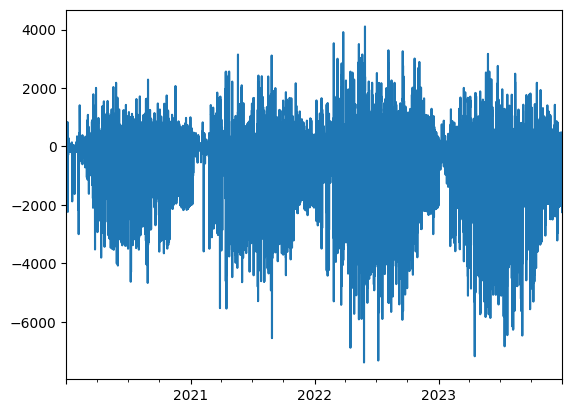

In [22]:
train_imputed['residual_add'].plot()

# This residual represents:

Residualt	​ = Productiont	​ −(Trendt	​+Seasonalt	​)

So ideally the residual should behave like random noise around zero if MSTL captured the structure well.

Let us Analyze this:

1. Residuals Are Centered Around Zero which indicates that the trend + seasonal components were correctly removed.
2. Residual Variance Is Not Constant
   We can clearly see blocks of different volatility:

    2020 → moderate variance
    
    2021 → higher variance
    
    2022 → very high variance
    
    2023 → different structure again
    Variance of residual is not constant,t his is heteroskedasticity.
3. Residual Still Shows Seasonal Envelope, this suggest MSTL has removed mean seasonality, but variance seasonality remains.
4. Negative Residuals Larger Than Positive (The negative spikes reach around -7000 and while positive spikes are around +4000) positive residuals are      limited since production cannot exceed physical limits much.
5. The residual now mainly contains:

    . cloud cover effects

    . atmospheric variability

    . short-term fluctuations

    Which are exactly the nonlinear patterns neural networks learn well. This residula is actually ideal for ML models.

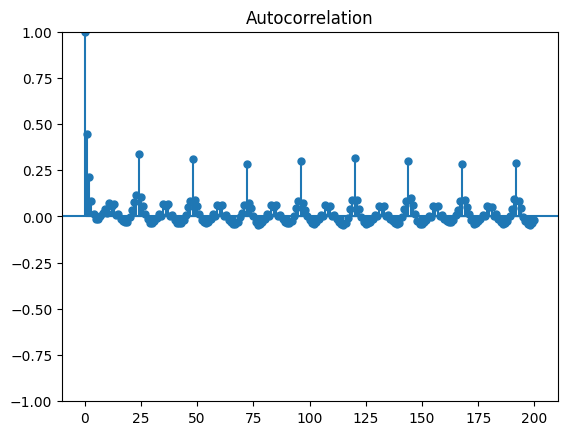

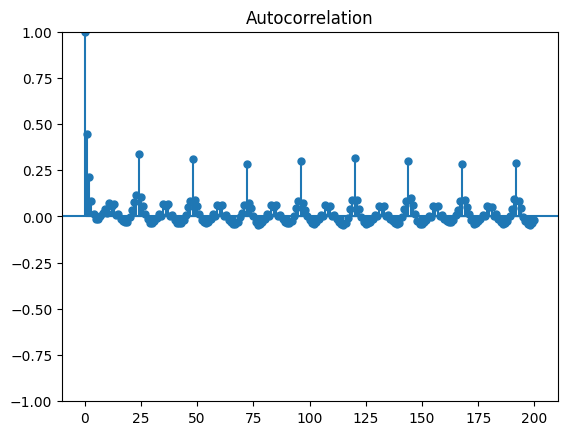

In [23]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(train_imputed['residual_add'], lags=200, alpha=0.5)

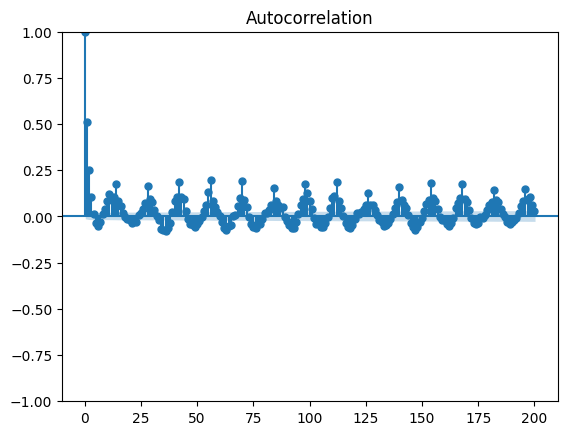

In [24]:
# Observing ACF & PACF only for solar production hours
res_day = train_imputed.loc[
    create_daylight_mask(train_imputed),
    'residual_add'
]

plot_acf(res_day, lags=200)
plt.show()

<Axes: >

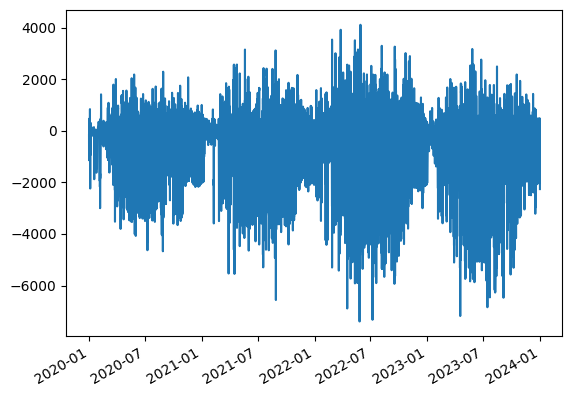

In [25]:
# Plot residuals only for solar production hours i.e daylight hours
train_imputed.loc[create_daylight_mask(train_imputed),'residual_add'].plot()

In [26]:
from statsmodels.tsa.stattools import acf
import pandas as pd
lags_to_check = [24, 48, 72, 96, 120, 168]

acf_values = acf(res_day, nlags=max(lags_to_check), fft=True)

acf_table = pd.DataFrame({
    "lag": lags_to_check,
    "acf": [acf_values[l] for l in lags_to_check]
})

acf_table

,lag,acf
0,24,0.006488
1,48,-0.043877
2,72,0.050586
3,96,0.063629
4,120,-0.015641
5,168,0.174564


All values are very close to zero except 168th, which shows MSTL removed daily cycle successfully.
Lag 168 → 0.175 this indicates the weekly weather regime correlation. This is exactly what TCN model should capture as a signal.

# Checking if after MSTL decomposition rest is cloud persistene

In [27]:
acf_values[1]

0.5104580598151847

Lag1 ≈ 0.51 - Short term memory

Lag168 ≈ 0.17 Long term memory

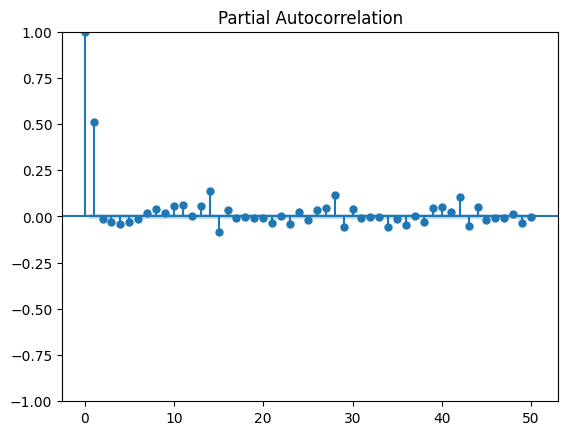

In [28]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(res_day, lags=50)
plt.show()

## What represents clear sky behaviour

ClearSkyProxy = Trend + Seasonal (24+8760)

In [29]:
clear_sky_proxy = trend + seasonal_24 + seasonal_8760

## Compute Clear-Sky Index (CSI)

CSIt = Production/ClearSkyProxy ( All at timestamp t)

In [30]:
mask = clear_sky_proxy > 0.1 * clear_sky_proxy.max()
# compute CSI
csi = train_imputed["Production"] / clear_sky_proxy
# 3️⃣ daylight mask
day_mask = create_daylight_mask(train_imputed)
csi_day = csi.loc[day_mask & mask]
csi_clean = csi_day.replace([np.inf,-np.inf],np.nan).dropna()

## Measure Cloud Persistence

In [31]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(csi_clean, nlags=10, fft=True)

for lag in range(1,6):
    print(f"Lag {lag}: {acf_vals[lag]:.3f}")

Lag 1: 0.493
Lag 2: 0.186
Lag 3: 0.031
Lag 4: -0.050
Lag 5: -0.086


Memory disappears after three hours as Lag 4: -0.050. Since we have seen above Lag1 ≈ 0.51 - Short term memory ,Lag168 ≈ 0.17 Long term memory TCN can 
help learn short and long term memory at the same time.

## Residual Test

In [32]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(residual, lags=[24,48,72], return_df=True)

,lb_stat,lb_pvalue
24,76959.634343,0.0
48,88440.771136,0.0
72,93155.412719,0.0


H0​:Residual series is white noise

Since all the p-values for lag24,lag48 & lag72 we can reject null hypothesis, which in-turn confirms temporal structure.

## What Structure remains in residual

#### Structure                    Evidence
1. Short memory:                   ACF(1) ≈ 0.51
2. Weather persistence:            CSI ACF
3. Weekly regimes:                 lag168 correlation
4. Ljung–Box:                      strong dependence

In short residual contains cloude persistence, weather regimes and multi-hour volatality

# TCN

## Residual scaling
1. Sky proxy has been used scale residual.
2. Considering timestamps only if it is 10% of its peak solar production( Excluding low radiance hours)

In [33]:
# Clear sky proxy from MSTL components
clear_sky_proxy = trend + seasonal_24 + seasonal_8760


# Cloud factor target
cloud_factor = train_imputed["Production"] / clear_sky_proxy

# Prevent extreme ratios caused by very small denominators
cloud_factor = cloud_factor.clip(0, 1.5)


# -------------------------------------------------------
# Keeping timestamp only if expected solar potential
# is at least 10% of the daily maximum
# -------------------------------------------------------

daily_max = clear_sky_proxy.resample("D").transform("max")

mask = clear_sky_proxy > 0.1 * daily_max


# Apply daylight mask
cloud_factor_day = cloud_factor.loc[mask]

# Remove NaNs
cloud_factor_day = cloud_factor_day.dropna()

In [34]:
mask.mean()

0.45722108145106094

In [35]:
ramp = train_imputed['Production'].diff()

from statsmodels.tsa.stattools import acf
acf(ramp.dropna(), nlags=10)

array([ 1.        ,  0.18606339,  0.08518429,  0.01842368, -0.0471121 ,
       -0.11205437, -0.14276274, -0.14083778, -0.14079363, -0.09960979,
       -0.0639156 ])

<Axes: >

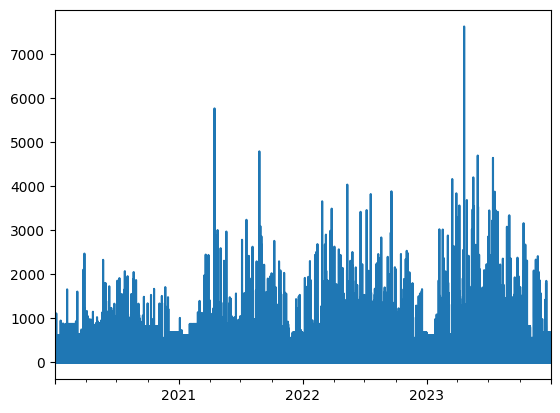

In [36]:
ramp.abs().rolling(6).mean().plot()

<Axes: >

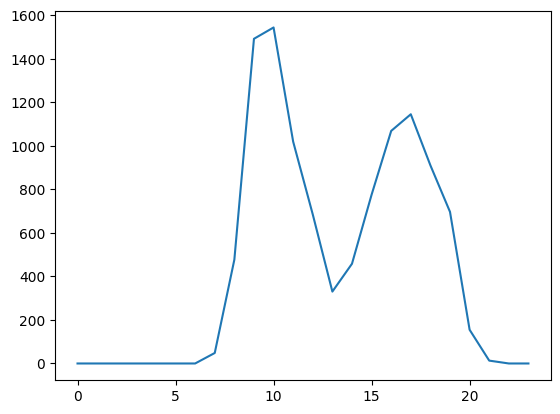

In [37]:
ramp.abs().groupby(train_imputed.index.hour).mean().plot()

# Information Decay / Memory Length plot diagnosis

Helps select TCN or LSTM.
It helps determine how far into the past the system retains useful predictive information. 

This is very useful for deciding:

TCN receptive field

input window length

whether long-memory models (LSTM/Transformer) are needed

#### Concept: 
How quickly correlation between the present and the past decays

ρ(k)=Corr(yt​,yt−k​)

## Compute the Memory Decay Curve

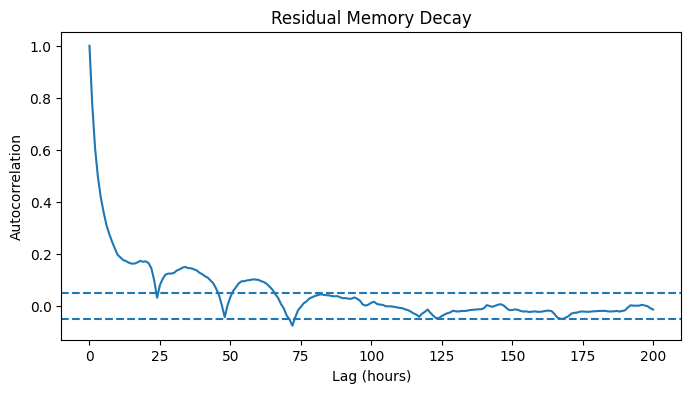

In [38]:
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import numpy as np

# residual from MSTL
series = residual.dropna()

acf_vals = acf(series, nlags=200, fft=True)

plt.figure(figsize=(8,4))
plt.plot(acf_vals)
plt.axhline(0.05, linestyle="--")
plt.axhline(-0.05, linestyle="--")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.title("Residual Memory Decay")
plt.show()

| Lag range | Avg correlation | Interpretation       |
| --------- | --------------- | -------------------- |
| 1–3       | ~0.63           | Strong persistence   |
| 4–6       | ~0.36           | Moderate persistence |
| 7–12      | ~0.22           | Weak persistence     |


In [39]:
# Capturing lags in dataframe to see actual values
lags = range(1, 20)

acf_df = pd.DataFrame({
    "lag_hour": lags,
    "autocorrelation": [acf_vals[l] for l in lags]
})

acf_df

,lag_hour,autocorrelation
0,1,0.772684
1,2,0.606085
2,3,0.495511
3,4,0.419230
4,5,0.362003
5,6,0.312565
6,7,0.277920
7,8,0.248261
8,9,0.221743
9,10,0.196670


In [40]:
from statsmodels.tsa.stattools import acf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# compute ACF
acf_vals = acf(residual.dropna(), nlags=50, fft=True)

# build table for first 12 lags
lags = range(1, 13)

acf_table = pd.DataFrame({
    "Lag (hour)": lags,
    "Autocorrelation": [acf_vals[l] for l in lags]
})

acf_table = acf_table.round(3)

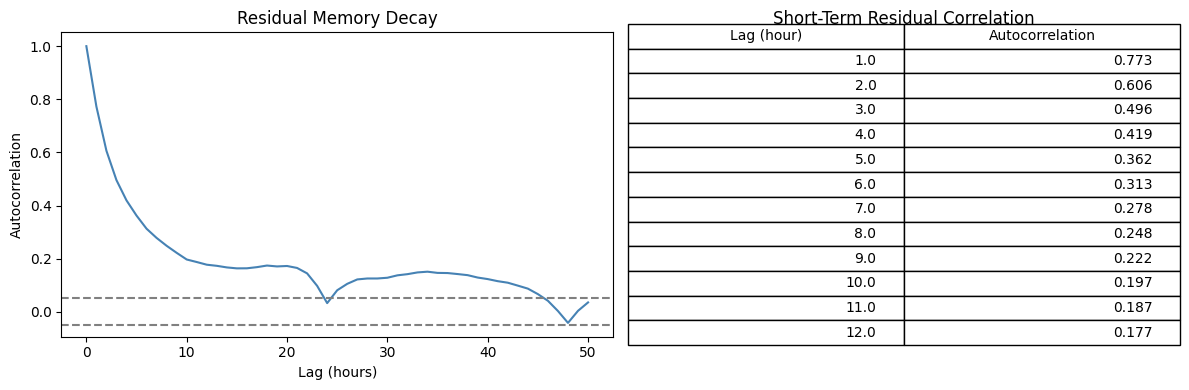

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# ---- ACF curve ----
ax[0].plot(acf_vals, color="steelblue")
ax[0].axhline(0.05, linestyle="--", color="gray")
ax[0].axhline(-0.05, linestyle="--", color="gray")

ax[0].set_title("Residual Memory Decay")
ax[0].set_xlabel("Lag (hours)")
ax[0].set_ylabel("Autocorrelation")

# ---- Table ----
ax[1].axis("off")

table = ax[1].table(
    cellText=acf_table.values,
    colLabels=acf_table.columns,
    loc="center"
)

table.scale(1,1.5)

ax[1].set_title("Short-Term Residual Correlation")

plt.tight_layout()
plt.show()

#### Residual Memory Decay Conclusion
The residual autocorrelation analysis shows strong short-term persistence, with lag-1 correlation of approximately 0.77 and gradually decaying correlations up to ~12 hours. This indicates that solar production residuals exhibit significant temporal dependence driven by cloud persistence and atmospheric dynamics. Consequently, temporal models such as TCN are well suited for capturing these dependencies.

# Building Single Diagnostic Dashboard

This dashboard summarizes
1. Residual memory (ACF) → shows temporal dependence.
2. Ramp-rate distribution → shows magnitude and frequency of abrupt changes.
3. Hourly volatility profile → shows when during the day variability occurs.

## Compute Required Series

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# residual series from MSTL
series = residual.dropna()

# ACF
acf_vals = acf(series, nlags=72, fft=True)

# ramp rates
ramp = train_imputed['Production'].diff().dropna()

# hourly volatility
hourly_vol = ramp.abs().groupby(ramp.index.hour).mean()

## Build the Dashboard Figure

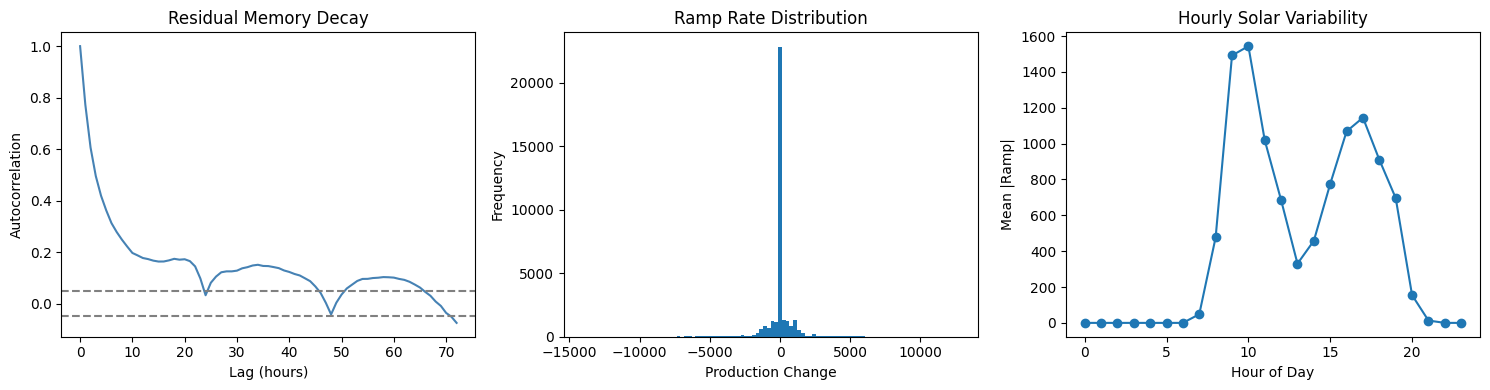

In [43]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

# ---- Panel 1: Residual Memory (ACF) ----
ax[0].plot(acf_vals, color="steelblue")
ax[0].axhline(0.05, linestyle="--", color="gray")
ax[0].axhline(-0.05, linestyle="--", color="gray")

ax[0].set_title("Residual Memory Decay")
ax[0].set_xlabel("Lag (hours)")
ax[0].set_ylabel("Autocorrelation")


# ---- Panel 2: Ramp Distribution ----
ax[1].hist(ramp.dropna(), bins=100)
ax[1].set_title("Ramp Rate Distribution")
ax[1].set_xlabel("Production Change")
ax[1].set_ylabel("Frequency")


# ---- Panel 3: Hourly Volatility ----
ax[2].plot(hourly_vol.index, hourly_vol.values, marker='o')
ax[2].set_title("Hourly Solar Variability")
ax[2].set_xlabel("Hour of Day")
ax[2].set_ylabel("Mean |Ramp|")

plt.tight_layout()
plt.show()

##### Conclusion
1. Residual Memory Decay (Left Panel):
   
       . Lag-1 correlation ≈ 0.75
       . Gradual decay across the first 10–15 hours
       . Small bumps around 24, 48, 72 hours
The residual series retains short-term temporal dependence, the secondary bumps around 24 hours indicate daily similarity in weather patterns, even though the deterministic solar cycle has already been removed by MSTL.

2. Ramp Rate Distribution (Middle Panel):  Rampt​=Productiont​−Productiont−1​
   
       . Distribution centered near 0
       . Heavy tails on both sides
       . Occasional very large ramps
Most of the time production changes gradually, but there are large ramps caused by cloud behaviour.

3. Hourly Solar Variability (Right Panel):
   | Hour  | Behavior               |
| ----- | ---------------------- |
| 00–06 | ~0 (night)             |
| 07–09 | rapid increase         |
| 09–11 | **maximum volatility** |
| 12–14 | moderate stability     |
| 15–18 | second volatility peak |
| 19–21 | decline                |

Solar variability is time-of-day dependent, reflecting the interaction between:

    .solar geometry

    .cloud motion

    .irradiance intensity
Volatility peaks shortly after sunrise and again in late afternoon.In order to cover this aspect we'll include time-of-day features which will help the model learn this structure.

##### Diagnostic Result:
Diagnostic analysis of the solar production time series. The residual autocorrelation (left) shows strong short-term persistence due to cloud dynamics. The ramp-rate distribution (center) exhibits heavy tails, indicating occasional large production changes. The hourly volatility profile (right) reveals time-of-day dependent variability driven by solar geometry and cloud movement. These characteristics justify the use of temporal deep learning models such as TCN for forecasting residual solar variability.

# MSTL Forecast -2024

In [44]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


def forecast_mstl_components(
    trend,
    seasonal_24,
    seasonal_8760,
    forecast_horizon=8760,
    forecast_start="2024-01-01"
):
    """
    Forecast clear-sky baseline using MSTL components.

    Parameters
    ----------
    trend : pd.Series
        Trend component from MSTL.

    seasonal_24 : pd.Series
        Daily seasonal component.

    seasonal_8760 : pd.Series
        Annual seasonal component.

    forecast_horizon : int
        Number of hours to forecast.

    forecast_start : str or pd.Timestamp
        Forecast start time.

    Returns
    -------
    pd.Series
        Forecasted clear sky values.
    """

    trend = pd.Series(trend)
    seasonal_24 = pd.Series(seasonal_24)
    seasonal_8760 = pd.Series(seasonal_8760)

    # -----------------------------
    # 1. Trend extrapolation
    # -----------------------------
    X = np.arange(len(trend)).reshape(-1, 1)

    lr = LinearRegression()
    lr.fit(X, trend.values)

    future_X = np.arange(
        len(trend),
        len(trend) + forecast_horizon
    ).reshape(-1, 1)

    trend_future = lr.predict(future_X)

    # -----------------------------
    # 2. Daily seasonal pattern
    # -----------------------------
    seasonal24_pattern = (
        seasonal_24
        .groupby(seasonal_24.index.hour)
        .mean()
        .values
    )

    seasonal24_future = np.tile(
        seasonal24_pattern,
        forecast_horizon // 24 + 1
    )[:forecast_horizon]

    # -----------------------------
    # 3. Annual seasonal pattern
    # -----------------------------
    annual_index = (
        seasonal_8760.index.dayofyear * 24
        + seasonal_8760.index.hour
    )

    seasonal8760_pattern = (
        seasonal_8760
        .groupby(annual_index)
        .mean()
        .values
    )

    seasonal8760_future = np.tile(
        seasonal8760_pattern,
        forecast_horizon // len(seasonal8760_pattern) + 1
    )[:forecast_horizon]

    # -----------------------------
    # 4. Combine components
    # -----------------------------
    forecast_values = (
        trend_future
        + seasonal24_future
        + seasonal8760_future
    )

    # prevent negative solar baseline
    forecast_values = np.clip(forecast_values, 0, None)

    # -----------------------------
    # 5. Forecast index
    # -----------------------------
    forecast_index = pd.date_range(
        start=forecast_start,
        periods=forecast_horizon,
        freq="h"
    )

    forecast_series = pd.Series(
        forecast_values,
        index=forecast_index,
        name="clear_sky_forecast"
    )

    return forecast_series

In [45]:
clean_sky_2024 = forecast_mstl_components(
                    trend,
                    seasonal_24,
                    seasonal_8760,
                    forecast_horizon=8760,
                    forecast_start="2024-01-01"
                )

In [46]:
daylight_mask = create_daylight_mask(clean_sky_2024.to_frame())

clean_sky_2024 = clean_sky_2024.where(daylight_mask, 0)

# Train TCN model on entire 2020-2023 using clear sky proxy derived cloud factor as target feature

## Change the feature

##### TCN Modelling Strategy
1. Capture clear sky proxy: Solar Production envelope.
2. Calculate Normalize Cloud Factor using clear sky proxy- Target Feature for TCN supervised learning

## Clear Sky Proxy Estimation Experiment

#### Method :                    What it estimates
1. Hour of year quantile:        Seasonal average production
2. Rolling 14 day quantile:       local clear-sky envelope

In [ ]:
# Hour of year quantile
solar["hour_of_year"] = (
    (solar.index.dayofyear - 1) * 24
    + solar.index.hour
)

df_day = solar[solar["Production"] > 0]

clear_profile = (
    df_day
    .groupby("hour_of_year")["Production"]
    .quantile(0.99)
)

solar["hour_of_year"] = (
    (solar.index.dayofyear - 1) * 24
    + solar.index.hour
)

clear_sky_proxy = solar["hour_of_year"].map(clear_profile)

In [ ]:
import matplotlib.pyplot as plt

year_mask = solar.index.year < 2024

actual = solar.loc[year_mask, "Production"]

plt.figure(figsize=(14,4))

plt.plot(actual.index, actual, label="Actual Production")
plt.plot(clear_sky_proxy.index, clear_sky_proxy, label="Clear Sky Proxy")

plt.title("Clear Sky vs Actual Production (2024)")
plt.legend()
plt.show()

In [ ]:
ratio = (solar["Production"] > clear_sky_proxy).mean()
print(ratio)

75 % of time Clear Sky Production is higher than actual production which is not good expected 95+. Also envelope is very much fluctuating.

In [ ]:
## Hour of year quantile
df_day = solar[solar["Production"] > 0].copy()
clear_sky_proxy = (
    df_day["Production"]
    .rolling(
        window=24*14,        # 14 days
        center=True,
        min_periods=24*3     # at least 3 days
    )
    .quantile(0.99)
)
clear_sky_proxy = clear_sky_proxy.rolling(
    window=24,
    center=True,
    min_periods=1
).mean()
clear_sky_proxy = clear_sky_proxy.reindex(solar.index)
clear_sky_proxy = clear_sky_proxy.interpolate()
cloud_factor = solar["Production"] / clear_sky_proxy
cloud_factor = cloud_factor.clip(0, 1.2)

train_mask = solar.index.year < 2024

cf_mean = cloud_factor.loc[train_mask].mean()
cf_std  = cloud_factor.loc[train_mask].std()

cloud_factor_norm = (cloud_factor - cf_mean) / cf_std

In [ ]:
ratio = (solar["Production"] > clear_sky_proxy).mean()
print(ratio)

99 % of time Clear Sky Production is higher than actual production which is good.

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(solar["Production"], label="Actual")
plt.plot(clear_sky_proxy, label="Clear Sky Proxy")

plt.legend()
plt.title("Clear Sky Envelope")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def prepare_tcn_data(
    cloud_factor_series,
    clear_sky_proxy,
    history=168,
    horizon=24,
    daylight_threshold=0.1
):

    # ---------------------------------
    # Daylight filtering
    # ---------------------------------

    daily_max = clear_sky_proxy.resample("D").transform("max")
    mask = clear_sky_proxy > daylight_threshold * daily_max

    cloud_factor_day = cloud_factor_series.loc[mask]
    clear_sky_day = clear_sky_proxy.loc[mask]

    # ---------------------------------
    # Build dataframe
    # ---------------------------------

    df = pd.DataFrame({
        "cloud_factor": cloud_factor_day,
        "clear_sky": clear_sky_day
    })

    # ---------------------------------
    # Lag features
    # ---------------------------------

    df["lag1"] = df["cloud_factor"].shift(1)
    df["lag24"] = df["cloud_factor"].shift(24)
    df["lag48"] = df["cloud_factor"].shift(48)
    df["lag168"] = df["cloud_factor"].shift(168)

    # ---------------------------------
    # Time features
    # ---------------------------------

    hour = df.index.hour

    df["hour_sin"] = np.sin(2*np.pi*hour/24)
    df["hour_cos"] = np.cos(2*np.pi*hour/24)

    df = df.dropna()

    # ---------------------------------
    # Feature columns
    # ---------------------------------

    feature_cols = [
        "cloud_factor",
        "lag1",
        "lag24",
        "lag48",
        "lag168",
        "hour_sin",
        "hour_cos",
        "clear_sky"
    ]

    values = df[feature_cols].values
    target = df["cloud_factor"].values

    # ---------------------------------
    # Create sequences
    # ---------------------------------

    X = []
    y = []

    for i in range(history, len(df) - horizon):

        X.append(values[i-history:i])
        y.append(target[i:i+horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y, df

In [ ]:
import numpy as np
import pandas as pd

def prepare_tcn_data(
    cloud_factor_series,
    clear_sky_proxy,
    history=168,
    horizon=24,
    daylight_threshold=0.1
):

    # ---------------------------------
    # Daylight filtering
    # ---------------------------------

    daily_max = clear_sky_proxy.resample("D").transform("max")
    mask = clear_sky_proxy > daylight_threshold * daily_max

    cloud_factor_day = cloud_factor_series.loc[mask]
    clear_sky_day = clear_sky_proxy.loc[mask]

    # ---------------------------------
    # Build dataframe
    # ---------------------------------

    df = pd.DataFrame({
        "cloud_factor": cloud_factor_day,
        "clear_sky": clear_sky_day
    })

    # ---------------------------------
    # Lag features
    # ---------------------------------

    df["lag1"] = df["cloud_factor"].shift(1)
    df["lag24"] = df["cloud_factor"].shift(24)
    df["lag48"] = df["cloud_factor"].shift(48)
    df["lag168"] = df["cloud_factor"].shift(168)

    # ---------------------------------
    # Time features
    # ---------------------------------

    hour = df.index.hour
    day  = df.index.dayofyear

    df["hour_sin"] = np.sin(2*np.pi*hour/24)
    df["hour_cos"] = np.cos(2*np.pi*hour/24)

    df["doy_sin"] = np.sin(2*np.pi*day/365)
    df["doy_cos"] = np.cos(2*np.pi*day/365)

    # ---------------------------------
    # Clean dataframe
    # ---------------------------------

    df = df.dropna()

    # ---------------------------------
    # Feature columns
    # ---------------------------------

    feature_cols = [
        "lag1",
        "lag24",
        "lag48",
        "lag168",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "clear_sky"
    ]

    values = df[feature_cols].values
    target = df["cloud_factor"].values

    # ---------------------------------
    # Create sequences
    # ---------------------------------

    X = []
    y = []

    for i in range(history, len(df) - horizon):

        X.append(values[i-history:i])
        y.append(target[i:i+horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y, df

In [ ]:
import numpy as np
import pandas as pd

def prepare_tcn_data(
    cloud_factor_series,
    clear_sky_proxy,
    history=168,
    horizon=24,
    daylight_threshold=0.1
):

    # ---------------------------------
    # Daylight filtering
    # ---------------------------------

    daily_max = clear_sky_proxy.resample("D").transform("max")
    mask = clear_sky_proxy > daylight_threshold * daily_max

    cloud_factor_day = cloud_factor_series.loc[mask]
    clear_sky_day = clear_sky_proxy.loc[mask]

    # ---------------------------------
    # Build dataframe
    # ---------------------------------

    df = pd.DataFrame({
        "cloud_factor": cloud_factor_day,
        "clear_sky": clear_sky_day
    })

    # ---------------------------------
    # Persistence feature
    # ---------------------------------

    df["lag1"] = df["cloud_factor"].shift(1)

    # ---------------------------------
    # Time features
    # ---------------------------------

    hour = df.index.hour
    day  = df.index.dayofyear

    df["hour_sin"] = np.sin(2*np.pi*hour/24)
    df["hour_cos"] = np.cos(2*np.pi*hour/24)

    df["doy_sin"] = np.sin(2*np.pi*day/365)
    df["doy_cos"] = np.cos(2*np.pi*day/365)

    # ---------------------------------
    # Clean dataframe
    # ---------------------------------

    df = df.dropna()

    # ---------------------------------
    # Feature columns
    # ---------------------------------

    feature_cols = [
        "cloud_factor",   # persistence anchor
        "lag1",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "clear_sky"
    ]

    values = df[feature_cols].values
    target = df["cloud_factor"].values

    # ---------------------------------
    # Create sequences
    # ---------------------------------

    X = []
    y = []

    for i in range(history, len(df) - horizon):

        X.append(values[i-history:i])
        y.append(target[i:i+horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y, df

In [ ]:
## Achha performance
import torch.nn as nn


def build_tcn_model(
    num_features,
    forecast_horizon=24,
    dilations=(1,2,4,8,16,32),
    channels=32,
    kernel_size=3,
    dropout=0.2
):
    """
    Build Temporal Convolutional Network architecture.

    Parameters
    ----------
    num_features : int
        Number of input features
    forecast_horizon : int
        Number of steps to forecast
    dilations : tuple
        Dilations for TCN layers
    channels : int
        Number of channels in each layer
    kernel_size : int
        Conv kernel size
    dropout : float
        Dropout rate

    Returns
    -------
    model : TCN
        Initialized TCN model
    """

    class TCNBlock(nn.Module):

        def __init__(self, in_channels, out_channels, kernel_size, dilation):
            super().__init__()

            padding = (kernel_size - 1) * dilation

            self.conv = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size,
                padding=padding,
                dilation=dilation
            )

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout)

            self.downsample = None
            if in_channels != out_channels:
                self.downsample = nn.Conv1d(in_channels, out_channels, 1)

        def forward(self, x):

            residual = x

            out = self.conv(x)

            if self.conv.padding[0] > 0:
                out = out[:, :, :-self.conv.padding[0]]

            out = self.relu(out)
            out = self.dropout(out)

            if self.downsample is not None:
                residual = self.downsample(residual)

            return self.relu(out + residual)


    class TCN(nn.Module):

        def __init__(self):
            super().__init__()

            layers = []
            in_ch = num_features

            for d in dilations:

                layers.append(
                    TCNBlock(
                        in_ch,
                        channels,
                        kernel_size,
                        d
                    )
                )

                in_ch = channels

            self.network = nn.Sequential(*layers)

            self.fc = nn.Linear(channels, forecast_horizon)

        def forward(self, x):

            out = self.network(x)

            out = out[:, :, -1]

            return self.fc(out)

    
    model = TCN()

    return model

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset


def train_tcn_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=30,
    batch_size=32,
    lr=0.001,
    patience=5,
    clip_grad=1.0,
    device="cpu"
):
    """
    Train TCN model with validation monitoring and early stopping.

    Returns
    -------
    model : trained model with best validation weights
    history : dictionary containing training history
    """

    model = model.to(device)

    # -----------------------
    # Loss function
    # -----------------------

    criterion = torch.nn.SmoothL1Loss()

    # -----------------------
    # Optimizer
    # -----------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    # -----------------------
    # LR scheduler
    # -----------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience=3,
        factor=0.5
    )

    # -----------------------
    # DataLoader
    # -----------------------

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    # -----------------------
    # Tracking
    # -----------------------

    best_val_loss = float("inf")
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    # -----------------------
    # Training loop
    # -----------------------

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(x_batch)

            loss = criterion(output, y_batch)

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                clip_grad
            )

            optimizer.step()

            total_loss += loss.item() * x_batch.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        # -----------------------
        # Validation
        # -----------------------

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val.to(device))
            val_loss = criterion(val_pred, y_val.to(device))

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss.item())

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f}"
        )

        # -----------------------
        # Early stopping
        # -----------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            best_model_state = model.state_dict()

        else:

            patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered")
                break

    # -----------------------
    # Restore best weights
    # -----------------------

    model.load_state_dict(best_model_state)

    return model, history

In [66]:
import numpy as np
import pandas as pd


def evaluate_forecast(actual_series, forecast_series):
    """
    Evaluate solar forecast accuracy.

    Parameters
    ----------
    actual_series : pd.Series
        Actual solar production indexed by datetime.

    forecast_series : pd.Series
        Forecasted solar production indexed by datetime.

    Returns
    -------
    dict
        Dictionary containing RMSE, MAE, MAPE, SMAPE, nRMSE.
    """

    # --------------------------
    # Align timestamps
    # --------------------------
    df = pd.concat(
        [actual_series, forecast_series],
        axis=1,
        join="inner"
    )

    df.columns = ["actual", "forecast"]

    # remove NaNs
    df = df.dropna()

    actual = df["actual"].values
    forecast = df["forecast"].values

    # --------------------------
    # Metrics
    # --------------------------

    mae = np.mean(np.abs(actual - forecast))

    rmse = np.sqrt(np.mean((actual - forecast) ** 2))

    # avoid division by zero
    mask = actual != 0
    mape = np.mean(
        np.abs((actual[mask] - forecast[mask]) / actual[mask])
    ) * 100

    smape = np.mean(
        2 * np.abs(forecast - actual) /
        (np.abs(actual) + np.abs(forecast) + 1e-8)
    ) * 100

    # normalized RMSE
    nrmse = rmse / np.mean(actual)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "SMAPE (%)": smape,
        "nRMSE": nrmse
    }

In [65]:
import torch
import numpy as np
import random

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# Use this block for cloud_factor_norm
X, y, df_features = prepare_tcn_data(
    cloud_factor_norm.loc[:'2023'],
    clear_sky_proxy.loc[:'2023'],
    history=168,
    horizon=24
)

In [ ]:
# Use this block for cloud_factor
X, y, df_features = prepare_tcn_data(
    cloud_factor.loc[:'2023'],
    clear_sky_proxy.loc[:'2023'],
    history=168,
    horizon=24
)

In [ ]:
train_size = int(len(X) * 0.85)
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:]
y_val = y[train_size:]

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0,2,1)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32).permute(0,2,1)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [ ]:
print(X_train.shape)
print(y_train.shape)

In [ ]:
num_features = X_train.shape[1]
set_seed(42)
model = build_tcn_model(
    num_features=num_features,
    forecast_horizon=24
)


In [ ]:
model, history = train_tcn_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=40,
    batch_size=32,
    lr=0.0005,
    patience=7,
    device="cpu"
)

Below is the output of multiple trail we did during the development:

Epoch 32 | Train Loss: 0.0354 | Val Loss: 0.0348 is the best Epoch  - With clipping

Epoch 39 | Train Loss: 0.1701 | Val Loss: 0.2138  is the best Epoch -- Without clipping

Epoch 40 | Train Loss: 0.4273 | Val Loss: 0.4503  is the best- With cloud Factor Normalized not delta

Epoch 28 | Train Loss: 0.4386 | Val Loss: 0.4751  is the best- with cloud factor seasonal features

Epoch 39 | Train Loss: 0.4111 | Val Loss: 0.4471 is the best- removed lag24/48/168

Epoch 40 | Train Loss: 0.0260 | Val Loss: 0.0235 is the best- Usinc cloud factor instead of normalized

In [ ]:
## Use this when using cloud factor as the target instead of normalized one
# ---------------------------------------
# Inference
# ---------------------------------------

model.eval()

with torch.no_grad():
    y_val_pred = model(X_val).cpu().numpy()

# ---------------------------------------
# True cloud factor values
# ---------------------------------------

y_val_true = y_val.cpu().numpy()

# ---------------------------------------
# Flatten arrays
# ---------------------------------------

y_val_pred_flat = y_val_pred.flatten()
y_val_true_flat = y_val_true.flatten()
y_val_pred_flat = np.clip(y_val_pred_flat, 0, 1.5)
# ---------------------------------------
# Build clear sky horizon matrix
# ---------------------------------------

clear_val = []

start_index = df_features.index[-len(y_val_pred):]

for t in start_index:

    horizon_index = pd.date_range(
        start=t,
        periods=24,
        freq="h"
    )

    clear_slice = clear_sky_proxy.reindex(horizon_index)

    clear_val.append(clear_slice.values)

clear_val = np.array(clear_val)
clear_val_flat = clear_val.flatten()

# ---------------------------------------
# Convert CF → production
# ---------------------------------------

production_pred = clear_val_flat * y_val_pred_flat
production_true = clear_val_flat * y_val_true_flat

# ---------------------------------------
# Metrics
# ---------------------------------------

metrics = evaluate_forecast(
    pd.Series(production_true),
    pd.Series(production_pred)
)

print(metrics)

In [ ]:
evaluate_forecast(
    pd.Series(y_val_true_flat),
    pd.Series(y_val_pred_flat)
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(production_true, label="Actual Production")
plt.plot(production_pred, label="Predicted Production")

plt.title("Actual vs Predicted Solar Production (Validation)")
plt.xlabel("Time Steps")
plt.ylabel("Production")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(production_true, production_pred, alpha=0.3)

max_val = max(production_true.max(), production_pred.max())
plt.plot([0, max_val], [0, max_val])  # perfect prediction line

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")

plt.title("Prediction vs Actual (Validation)")
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(y_val_true_flat, label="Actual Cloud Factor")
plt.plot(y_val_pred_flat, label="Predicted Cloud Factor")

plt.title("Actual vs Predicted Cloud Factor")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
week = slice(0, 24*7)

plt.figure(figsize=(14,5))
plt.plot(production_true[week], label="Actual")
plt.plot(production_pred[week], label="Predicted")
plt.legend()
plt.grid(True)

In [ ]:
# ---------------------------------------
# Inference
# ---------------------------------------

model.eval()

with torch.no_grad():
    y_val_pred = model(X_val).cpu().numpy()

# ---------------------------------------
# De-normalize cloud factor
# ---------------------------------------

y_val_pred = y_val_pred * cf_std + cf_mean
y_val_true = y_val.cpu().numpy() * cf_std + cf_mean

# ---------------------------------------
# Flatten arrays
# ---------------------------------------

y_val_pred_flat = y_val_pred.flatten()
y_val_true_flat = y_val_true.flatten()

# ---------------------------------------
# Build clear sky horizon matrix
# ---------------------------------------

clear_val = []

start_index = df_features.index[-len(y_val_pred):]

for t in start_index:

    horizon_index = pd.date_range(
        start=t,
        periods=24,
        freq="h"
    )

    clear_slice = clear_sky_proxy.reindex(horizon_index)

    clear_val.append(clear_slice.values)

clear_val = np.array(clear_val)
clear_val_flat = clear_val.flatten()

# ---------------------------------------
# Convert CF → production
# ---------------------------------------

production_pred = clear_val_flat * y_val_pred_flat
production_true = clear_val_flat * y_val_true_flat

# ---------------------------------------
# Metrics
# ---------------------------------------

metrics = evaluate_forecast(
    pd.Series(production_true),
    pd.Series(production_pred)
)

print(metrics)

In [ ]:
# Model-3
np.corrcoef(y_val_true_flat, y_val_pred_flat)[0,1]

In [ ]:
plt.plot(y_val_pred_flat[:500])
plt.title("Predicted Delta CF")

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_val_true_flat, y_val_pred_flat, alpha=0.3)

plt.xlabel("True ΔCF")
plt.ylabel("Predicted ΔCF")
plt.title("True vs Predicted Delta CF Scatter")

# reference line
plt.plot(
    [y_val_true_flat.min(), y_val_true_flat.max()],
    [y_val_true_flat.min(), y_val_true_flat.max()],
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_val_true_flat, bins=50)
plt.title("True Delta CF Distribution")
plt.show()

In [ ]:
# Model-3
plt.figure(figsize=(12,4))
plt.plot(y_val_true_flat[:500], label="True CF")
plt.plot(y_val_pred_flat[:500], label="Predicted CF")
plt.legend()
plt.show()

Model has learnt shape of the data but it clearly lags the feature it required to capture the amplitude.

In [ ]:
# Model-3
plt.hist(cloud_factor, bins=50)

In [ ]:
# MOdel-3
np.corrcoef(
    X_train[:, -1, 0],   # last timestep of feature
    y_train[:, 0]        # next timestep target
)

The input feature and the target are correlated but very less.

In [ ]:
persistence_pred = X_val[:, -1, 0]

np.corrcoef(persistence_pred, y_val[:,0])[0,1]

We are not able to beat the persistence model. Although it is very much common in case of solar forecast cloud factor forecast.

## Re-train till 2023 data

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset


def retrain_tcn_full_data(
    model,
    X_train,
    y_train,
    best_epoch,
    batch_size=32,
    lr=0.0005,
    clip_grad=1.0,
    device="cpu"
):

    # ---------------------------------
    # Move model to device
    # ---------------------------------

    model = model.to(device)

    # ---------------------------------
    # Dataset + Loader
    # ---------------------------------

    train_dataset = TensorDataset(X_train, y_train)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # ---------------------------------
    # Loss + Optimizer
    # ---------------------------------

    criterion = torch.nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    # ---------------------------------
    # History tracker
    # ---------------------------------

    history = {"train_loss": []}

    print("=== Retraining on Full Data ===")
    print("Training tensor shape:", X_train.shape)
    print("Target tensor shape:", y_train.shape)
    print("Model first conv:", model.network[0].conv)
    print("================================")

    # ---------------------------------
    # Training loop
    # ---------------------------------

    for epoch in range(best_epoch):

        model.train()

        total_loss = 0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(x_batch)

            loss = criterion(output, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                clip_grad
            )

            optimizer.step()

            total_loss += loss.item() * x_batch.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        history["train_loss"].append(train_loss)

        print(f"Epoch {epoch+1}/{best_epoch} | Train Loss: {train_loss:.4f}")

    print("=== Retraining Complete ===")

    return model, history

In [ ]:
X_train, y_train, df_features = prepare_tcn_data(
    cloud_factor_norm.loc[:'2023'],
    clear_sky_proxy.loc[:'2023'],
    history=168,
    horizon=24
)
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0,2,1)
y_train = torch.tensor(y_train, dtype=torch.float32)


In [ ]:
print(X_train.shape)
print(y_train.shape)

In [ ]:
num_features = X_train.shape[1]
set_seed(42)
model = build_tcn_model(
    num_features=num_features,
    forecast_horizon=24
)


In [ ]:
print("Batch input shape:", X_train.shape)
print("Model first layer:", model.network[0].conv)

In [ ]:
best_epoch = 12
model, history = retrain_tcn_full_data(
    model,
    X_train,
    y_train,
    best_epoch=best_epoch,
    batch_size=32,
    lr=0.0005,
    device="cpu"
)

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "best_epoch": best_epoch,
    "num_features": X_train.shape[1],
    "history_window": X_train.shape[2],
    "forecast_horizon": y_train.shape[1]
}, "tcn_solar_envelope_model_2020_2023.pt")

In [ ]:
import torch

# -----------------------------
# Load checkpoint
# -----------------------------

checkpoint = torch.load("tcn_solar_envelope_model_2020_2023.pt", map_location="cpu")

# -----------------------------
# Rebuild architecture
# -----------------------------

model_solar_env = build_tcn_model(
    num_features=checkpoint["num_features"],
    forecast_horizon=checkpoint["forecast_horizon"]
)

# -----------------------------
# Load weights
# -----------------------------

model_solar_env.load_state_dict(checkpoint["model_state_dict"])

# -----------------------------
# Set model to evaluation mode
# -----------------------------

model_solar_env.eval()

print("Model loaded successfully")
print("Features:", checkpoint["num_features"])
print("History window:", checkpoint["history_window"])
print("Forecast horizon:", checkpoint["forecast_horizon"])

### Forecast 2024

In [ ]:
import numpy as np
import pandas as pd


def prepare_forecast_features(index, clear_sky_proxy):

    df = pd.DataFrame(index=index)

    # clear sky
    df["clear_sky"] = clear_sky_proxy.reindex(index)

    # time features
    hour = df.index.hour
    day = df.index.dayofyear

    df["hour_sin"] = np.sin(2*np.pi*hour/24)
    df["hour_cos"] = np.cos(2*np.pi*hour/24)

    df["doy_sin"] = np.sin(2*np.pi*day/365)
    df["doy_cos"] = np.cos(2*np.pi*day/365)

    return df

In [ ]:
import numpy as np
import pandas as pd
import torch


def forecast_2024_tcn(
    model,
    cloud_factor_norm,
    clear_sky_proxy,
    history=168,
    horizon=24,
    device="cpu"
):

    model = model.to(device)
    model.eval()

    # ----------------------------------
    # Forecast index for 2024
    # ----------------------------------

    forecast_index = pd.date_range(
        start="2024-01-01 00:00:00",
        end="2024-12-31 23:00:00",
        freq="h"
    )

    # ----------------------------------
    # Initialize CF history
    # ----------------------------------

    cf_history = list(
        cloud_factor_norm.loc[:'2023'].iloc[-history:]
    )

    preds = []

    # ----------------------------------
    # Recursive forecasting loop
    # ----------------------------------

    for ts in forecast_index:

        window = []

        for i in range(history):

            past_ts = ts - pd.Timedelta(hours=history - i)

            cf_val = cf_history[-history + i]

            hour = past_ts.hour
            day = past_ts.dayofyear

            row = [
                cf_val,  # cloud_factor
                cf_val,  # lag1
                np.sin(2*np.pi*hour/24),
                np.cos(2*np.pi*hour/24),
                np.sin(2*np.pi*day/365),
                np.cos(2*np.pi*day/365),
                float(clear_sky_proxy.loc[past_ts])
            ]

            window.append(row)

        # ----------------------------------
        # Convert window to tensor
        # ----------------------------------

        x = (
            torch.tensor(np.array(window), dtype=torch.float32)
            .unsqueeze(0)
            .permute(0, 2, 1)
            .to(device)
        )

        # ----------------------------------
        # Predict next CF
        # ----------------------------------

        with torch.no_grad():

            pred = model(x).cpu().numpy().flatten()[0]

        # Stabilize recursive CF
        pred = np.clip(pred, -2, 2)

        preds.append(pred)

        cf_history.append(pred)

    # ----------------------------------
    # Build forecast series
    # ----------------------------------

    forecast_cf = pd.Series(preds, index=forecast_index)

    return forecast_cf

In [ ]:
# ---------------------------
# 1. Fix clear sky index (training period)
# ---------------------------

clear_sky_train = (
    clear_sky_proxy.loc[:'2023']
    .sort_index()
    .asfreq("h")
    .interpolate()
)

# ---------------------------
# 2. Extend clear sky using hour-of-year climatology
# ---------------------------
# ---------------------------
# Extend clear sky using hour-of-year climatology
# ---------------------------

# compute hour-of-year for training data
hour_of_year = (clear_sky_train.index.dayofyear - 1) * 24 + clear_sky_train.index.hour

# mean clear sky for each hour-of-year
climatology = clear_sky_train.groupby(hour_of_year).mean()

# create 2024 hourly index
index_2024 = pd.date_range(
    "2024-01-01 00:00",
    "2024-12-31 23:00",
    freq="h"
)

hour_of_year_2024 = (index_2024.dayofyear - 1) * 24 + index_2024.hour

clear_sky_2024 = pd.Series(
    climatology.reindex(hour_of_year_2024).values,
    index=index_2024
)

# combine training + forecast clear sky
clear_sky_full = pd.concat([clear_sky_train, clear_sky_2024])

# ---------------------------
# 3. Prepare training data
# ---------------------------

X_train, y_train, df_features = prepare_tcn_data(
    cloud_factor_norm.loc[:'2023'],
    clear_sky_train,
    history=168,
    horizon=24
)

# ---------------------------
# 4. Forecast 2024 cloud factor
# ---------------------------

forecast_cf = forecast_2024_tcn(
    model,
    cloud_factor_norm.loc[:'2023'],
    clear_sky_full
)

forecast_cf = forecast_cf.clip(-2, 2)

forecast_cf_denorm = forecast_cf * cf_std + cf_mean
forecast_cf_denorm = forecast_cf_denorm.clip(0, 1.2)

# ---------------------------
# 5. Convert CF → Production
# ---------------------------

production_2024 = forecast_cf_denorm * clear_sky_full.loc[forecast_cf_denorm.index]

In [ ]:
actual_2024 = solar.loc['2024', ['Production']]

metrics = evaluate_forecast(
    pd.Series(actual_2024["Production"]),
    pd.Series(production_2024)
)

print(metrics)


## Let's check the predictive power of cloud factor

In [ ]:
import numpy as np

cf_actual = solar["Production"].reindex(clear_sky_proxy.index) / clear_sky_proxy
cf_actual = cf_actual.replace([np.inf, -np.inf], np.nan)
cf_actual = cf_actual.clip(lower=0, upper=1.2)

In [ ]:
plt.figure(figsize=(14,4))
cf_actual.plot()
plt.title("Cloud Factor (Actual)")
plt.grid(True)

In [ ]:
cf_actual.groupby(cf_actual.index.hour).mean().plot()

In [ ]:
week = slice("2022-06-01", "2022-06-07")

plt.figure(figsize=(14,4))
plt.plot(cf_actual.loc[week], label="Actual CF")
plt.legend()
plt.grid()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(cf_actual.dropna(), lags=48)
plt.show()

In [ ]:
cf_actual.groupby(cf_actual.index.hour).std().plot()

In [ ]:
cf_actual.hist(bins=50)

In [ ]:
y.mean(), y.std()

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------
# Align timestamps
# ---------------------------------

actual_series = actual_2024["Production"]

pred_series = production_2024.reindex(actual_series.index)

# ---------------------------------
# Plot
# ---------------------------------

plt.figure(figsize=(14,5))

plt.plot(actual_series.index, actual_series.values, label="Actual Production")
plt.plot(pred_series.index, pred_series.values, label="Forecast Production")

plt.title("Solar Production Forecast vs Actual (2024)")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
week_slice = slice("2024-06-01", "2024-06-07")

plt.figure(figsize=(14,5))

plt.plot(actual_series.loc[week_slice], label="Actual")
plt.plot(pred_series.loc[week_slice], label="Forecast")

plt.title("Hourly Solar Production (Sample Week)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
actual_2024 = solar.loc['2024', ['Production']]

metrics = evaluate_forecast(
    pd.Series(production_true),
    pd.Series(production_pred)
)

print(metrics)



In [ ]:
print(forecast_cf.describe())

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(forecast_cf[:500])
plt.title("Forecast Cloud Factor")
plt.show()

## Building TCN using clear sky proxy from MSTL decomposition

In [47]:
# Clear sky proxy from MSTL components
clear_sky_proxy = trend + seasonal_24 + seasonal_8760


# Cloud factor target
cloud_factor = train_imputed["Production"] / clear_sky_proxy

# Prevent extreme ratios caused by very small denominators
cloud_factor = cloud_factor.clip(0.05, 1.5)
# -------------------------------------------------------
# Keeping timestamp only if expected solar potential
# is at least 10% of the daily maximum
# -------------------------------------------------------

daily_max = clear_sky_proxy.resample("D").transform("max")

mask = clear_sky_proxy > 0.1 * daily_max


# Apply daylight mask
cloud_factor_day = cloud_factor.loc[mask]

# Remove NaNs
cloud_factor_day = cloud_factor_day.dropna()

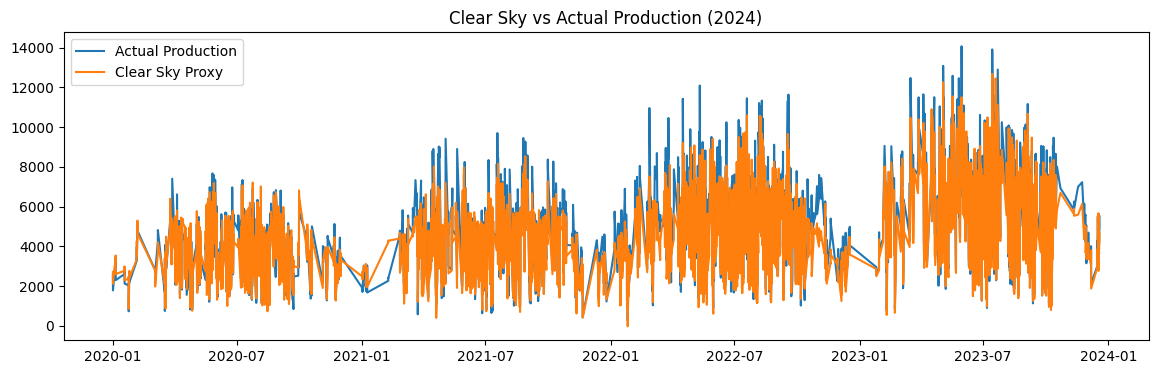

In [48]:
import matplotlib.pyplot as plt

year_mask = solar.index.year < 2024

actual = solar.loc[year_mask, "Production"]

clear = (
    clear_sky_proxy
    .reindex(solar.index)   # align indices
    .loc[year_mask]
)

plt.figure(figsize=(14,4))

plt.plot(actual.index, actual, label="Actual Production")
plt.plot(clear.index, clear, label="Clear Sky Proxy")

plt.title("Clear Sky vs Actual Production (2024)")
plt.legend()
plt.show()

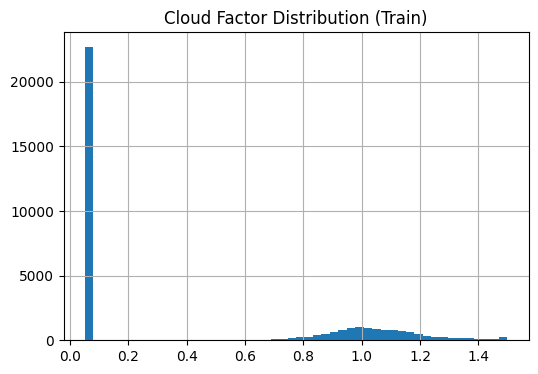

In [49]:
plt.figure(figsize=(6,4))
cloud_factor.loc["2020":"2023"].hist(bins=50)
plt.title("Cloud Factor Distribution (Train)")
plt.show()

In [50]:
import numpy as np
import pandas as pd


def prepare_tcn_data(
    cloud_factor_series,
    clear_sky_proxy,
    history=168,
    horizon=24,
    daylight_threshold=0.1
):
    """
    Prepare cloud factor data for TCN training.

    Target
    ------
    cloud_factor = actual / clear_sky_proxy

    Features
    --------
    cloud_factor
    lag24, lag48, lag168
    hour_sin, hour_cos
    day_sin, day_cos
    clear_sky_proxy (baseline magnitude)

    Steps
    -----
    1. Daylight filtering
    2. Create lag features
    3. Create cyclical time features
    4. Add baseline magnitude feature
    5. Remove NaNs
    6. Create TCN sequences
    """

    # ------------------------------------------------
    # 1 Daylight filtering
    # ------------------------------------------------

    daily_max = clear_sky_proxy.resample("D").transform("max")

    mask = clear_sky_proxy > daylight_threshold * daily_max

    cloud_factor_day = cloud_factor_series.loc[mask]
    clear_sky_day = clear_sky_proxy.loc[mask]
    
    # daily_max = clear_sky_proxy.resample("D").transform("max")

    # mask = clear_sky_proxy > daylight_threshold * daily_max
    
    # cloud_factor_day = cloud_factor_series.loc[mask]
    # ------------------------------------------------
    # 2 Convert to dataframe
    # ------------------------------------------------

    df = pd.DataFrame({
        "cloud_factor": cloud_factor_day,
        "clear_sky": clear_sky_day
    })

    # ------------------------------------------------
    # 3 Lag features
    # ------------------------------------------------
    df["lag1"] = df["cloud_factor"].shift(1)
    df["lag24"] = df["cloud_factor"].shift(24)
    df["lag48"] = df["cloud_factor"].shift(48)
    df["lag168"] = df["cloud_factor"].shift(168)

    # ------------------------------------------------
    # 4 Time features
    # ------------------------------------------------

    hour = df.index.hour
    dayofyear = df.index.dayofyear

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    df["day_sin"] = np.sin(2 * np.pi * dayofyear / 365)
    df["day_cos"] = np.cos(2 * np.pi * dayofyear / 365)

    # ------------------------------------------------
    # 5 Remove NaNs (caused by lags)
    # ------------------------------------------------

    df = df.dropna()

    # ------------------------------------------------
    # 6 Create sequences for TCN
    # ------------------------------------------------

    feature_cols = [
        "lag1",
        "cloud_factor",
        "lag24",
        "lag48",
        "lag168",
        "hour_sin",
        "hour_cos",
        "day_sin",
        "day_cos",
        "clear_sky"
    ]

    values = df[feature_cols].values
    target = df["cloud_factor"].values

    X = []
    y = []

    for i in range(history, len(df) - horizon):

        X.append(values[i-history:i])
        y.append(target[i:i+horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y, df

In [51]:
## Achha performance
import torch.nn as nn


def build_tcn_model(
    num_features,
    forecast_horizon=24,
    dilations=(1,2,4,8,16,32),
    channels=32,
    kernel_size=3,
    dropout=0.2
):
    """
    Build Temporal Convolutional Network architecture.

    Parameters
    ----------
    num_features : int
        Number of input features
    forecast_horizon : int
        Number of steps to forecast
    dilations : tuple
        Dilations for TCN layers
    channels : int
        Number of channels in each layer
    kernel_size : int
        Conv kernel size
    dropout : float
        Dropout rate

    Returns
    -------
    model : TCN
        Initialized TCN model
    """

    class TCNBlock(nn.Module):

        def __init__(self, in_channels, out_channels, kernel_size, dilation):
            super().__init__()

            padding = (kernel_size - 1) * dilation

            self.conv = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size,
                padding=padding,
                dilation=dilation
            )

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout)

            self.downsample = None
            if in_channels != out_channels:
                self.downsample = nn.Conv1d(in_channels, out_channels, 1)

        def forward(self, x):

            residual = x

            out = self.conv(x)

            if self.conv.padding[0] > 0:
                out = out[:, :, :-self.conv.padding[0]]

            out = self.relu(out)
            out = self.dropout(out)

            if self.downsample is not None:
                residual = self.downsample(residual)

            return self.relu(out + residual)


    class TCN(nn.Module):

        def __init__(self):
            super().__init__()

            layers = []
            in_ch = num_features

            for d in dilations:

                layers.append(
                    TCNBlock(
                        in_ch,
                        channels,
                        kernel_size,
                        d
                    )
                )

                in_ch = channels

            self.network = nn.Sequential(*layers)

            self.fc = nn.Linear(channels, forecast_horizon)

        def forward(self, x):

            out = self.network(x)

            out = out[:, :, -1]

            return self.fc(out)

    
    model = TCN()

    return model

In [52]:
## Achha performance
import torch
from torch.utils.data import DataLoader, TensorDataset


def train_tcn_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=30,
    batch_size=32,
    lr=0.001,
    patience=5,
    clip_grad=1.0,
    device="cpu"
):
    """
    Train TCN model with validation monitoring and early stopping.

    Returns
    -------
    model : trained model with best validation weights
    history : dictionary containing training history
    """

    model = model.to(device)

    # -----------------------
    # Loss function
    # -----------------------

    criterion = torch.nn.SmoothL1Loss()

    # -----------------------
    # Optimizer
    # -----------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    # -----------------------
    # LR scheduler
    # -----------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience=3,
        factor=0.5
    )

    # -----------------------
    # DataLoader
    # -----------------------

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    # -----------------------
    # Tracking
    # -----------------------

    best_val_loss = float("inf")
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    # -----------------------
    # Training loop
    # -----------------------

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(x_batch)

            loss = criterion(output, y_batch)

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                clip_grad
            )

            optimizer.step()

            total_loss += loss.item() * x_batch.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        # -----------------------
        # Validation
        # -----------------------

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val.to(device))
            val_loss = criterion(val_pred, y_val.to(device))

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss.item())

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f}"
        )

        # -----------------------
        # Early stopping
        # -----------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            best_model_state = model.state_dict()

        else:

            patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered")
                break

    # -----------------------
    # Restore best weights
    # -----------------------

    model.load_state_dict(best_model_state)

    return model, history

In [54]:
import numpy as np
import pandas as pd


def evaluate_forecast(actual_series, forecast_series):
    """
    Evaluate solar forecast accuracy.

    Parameters
    ----------
    actual_series : pd.Series
        Actual solar production indexed by datetime.

    forecast_series : pd.Series
        Forecasted solar production indexed by datetime.

    Returns
    -------
    dict
        Dictionary containing RMSE, MAE, MAPE, SMAPE, nRMSE.
    """

    # --------------------------
    # Align timestamps
    # --------------------------
    df = pd.concat(
        [actual_series, forecast_series],
        axis=1,
        join="inner"
    )

    df.columns = ["actual", "forecast"]

    # remove NaNs
    df = df.dropna()

    actual = df["actual"].values
    forecast = df["forecast"].values

    # --------------------------
    # Metrics
    # --------------------------

    mae = np.mean(np.abs(actual - forecast))

    rmse = np.sqrt(np.mean((actual - forecast) ** 2))

    # avoid division by zero
    mask = actual != 0
    mape = np.mean(
        np.abs((actual[mask] - forecast[mask]) / actual[mask])
    ) * 100

    smape = np.mean(
        2 * np.abs(forecast - actual) /
        (np.abs(actual) + np.abs(forecast) + 1e-8)
    ) * 100

    # normalized RMSE
    nrmse = rmse / np.mean(actual)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "SMAPE (%)": smape,
        "nRMSE": nrmse
    }

In [55]:
cloud_factor.dropna(inplace=True)

In [59]:
X, y, df_features = prepare_tcn_data(
    cloud_factor,
    clear_sky_proxy,
    history=168,
    horizon=24
)

In [61]:
train_size = int(len(X) * 0.8) # Achha performance
# train_size = int(len(X) * 0.85)
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:]
y_val = y[train_size:]


In [62]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32).permute(0,2,1)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32).permute(0,2,1)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [63]:
print(X_train.shape)
print(y_train.shape)

torch.Size([12535, 10, 168])
torch.Size([12535, 24])


In [67]:
num_features = X_train.shape[1]
set_seed(42)
model = build_tcn_model(
    num_features=num_features,
    forecast_horizon=24
)

## Uncomment below cell only if you want to train the model -on train-val dataset for model selection

In [ ]:
# model, history = train_tcn_model(
#     model,
#     X_train,
#     y_train,
#     X_val,
#     y_val,
#     epochs=40,
#     batch_size=32,
#     lr=0.0005,
#     patience=7,
#     device="cpu"
# )

Epoch 19 | Train Loss: 0.1234 | Val Loss: 0.1283 - best epoch using 10 features - ['cloud_factor', 'clear_sky', 'lag1', 'lag24', 'lag48', 'lag168',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

In [ ]:
# Achha performance
model.eval()

with torch.no_grad():
    y_val_pred = model(X_val).cpu().numpy()

In [ ]:
cf_pred_step1 = y_val_pred[:, 0]
cf_pred_step1 = np.clip(cf_pred_step1, 0, 1.2)
cf_pred_series = pd.Series(
    cf_pred_step1,
    index=cloud_factor_day.index[-len(cf_pred_step1):]
)
val_production_pred = cf_pred_series * clear_sky_proxy.loc[cf_pred_series.index]

In [ ]:
# Find common timestamps
common_idx = val_production_pred.index.intersection(solar.index)

# Align both series
actual = solar.loc[common_idx, "Production"]
pred   = val_production_pred.loc[common_idx]

# Plot
plt.figure(figsize=(14,5))

plt.plot(actual, label="Actual", linewidth=1.5)
plt.plot(pred, label="Prediction", linewidth=1.5)

plt.legend()
plt.grid()

In [ ]:
print(np.min(cf_pred_step1))
print(np.max(cf_pred_step1))
print(np.mean(cf_pred_step1))

Now our cloud factor is within range
| Condition              | Cloud Factor |
| ---------------------- | ------------ |
| Clear sky              | 0.9 – 1.05   |
| Thin cloud enhancement | 1.05 – 1.2   |
| Cloudy                 | 0.2 – 0.8    |
| Night                  | 0            |


In [ ]:
metrics = evaluate_forecast(
    pd.Series(actual),
    pd.Series(pred)
)

print(metrics)

Solar Production
     │
     ▼
MSTL (trend + seasonal)
     │
     ▼
ClearSky baseline
     │
     ▼
TCN predicts CloudFactor
     │
     ▼
Final Forecast = ClearSky × CloudFactor

## Re-train the Model till 2023

In [68]:
import torch
from torch.utils.data import DataLoader, TensorDataset


def retrain_tcn_full_data(
    model,
    X_train,
    y_train,
    best_epoch,
    batch_size=32,
    lr=0.0005,
    clip_grad=1.0,
    device="cpu"
):

    model = model.to(device)

    criterion = torch.nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    history = {"train_loss": []}

    for epoch in range(best_epoch):

        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(x_batch)

            loss = criterion(output, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                clip_grad
            )

            optimizer.step()

            total_loss += loss.item() * x_batch.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        history["train_loss"].append(train_loss)

        print(
            f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}"
        )

    return model, history

In [112]:
import numpy as np
import pandas as pd
import torch


def forecast_2024_daily_teacher_forcing(
    model,
    clear_sky_2024,
    actual_production,
    history=168,
    device="cpu"
):

    model.eval()
    model.to(device)

    forecast_index = clear_sky_2024.index

    # compute cloud factor from actual history
    clear_sky_full = clear_sky_2024.reindex(actual_production.index).fillna(0)
    cloud_factor = actual_production / clear_sky_full.replace(0, np.nan)
    cloud_factor = cloud_factor.fillna(0)

    forecasts = []

    feature_cols = [
        "cloud_factor",
        "lag1",
        "lag24",
        "lag48",
        "lag168",
        "hour_sin",
        "hour_cos",
        "day_sin",
        "day_cos",
        "clear_sky",
    ]

    for day_start in pd.date_range("2024-01-01", "2024-12-31", freq="D"):

        ts = day_start

        df = pd.DataFrame(index=actual_production.index)

        df["cloud_factor"] = cloud_factor
        df["clear_sky"] = clear_sky_2024.reindex(df.index).fillna(0)

        df["lag1"] = df["cloud_factor"].shift(1)
        df["lag24"] = df["cloud_factor"].shift(24)
        df["lag48"] = df["cloud_factor"].shift(48)
        df["lag168"] = df["cloud_factor"].shift(168)

        hour = df.index.hour
        day = df.index.dayofyear

        df["hour_sin"] = np.sin(2*np.pi*hour/24)
        df["hour_cos"] = np.cos(2*np.pi*hour/24)

        df["day_sin"] = np.sin(2*np.pi*day/365)
        df["day_cos"] = np.cos(2*np.pi*day/365)

        seq = df.loc[:ts].iloc[-history:][feature_cols].values

        x = torch.tensor(seq.T, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            preds = model(x).cpu().numpy().flatten()

        preds = np.clip(preds, 0, 1.25)

        forecasts.extend(preds)

    forecasts = np.array(forecasts[:len(forecast_index)])

    solar_forecast = forecasts * clear_sky_2024.values

    return pd.Series(
        solar_forecast,
        index=forecast_index,
        name="solar_forecast_2024"
    )

In [73]:
X_train, y_train, df_features = prepare_tcn_data(
    cloud_factor,
    clear_sky_proxy,
    history=168,
    horizon=24
)

import torch

X_train = torch.tensor(X_train, dtype=torch.float32).permute(0,2,1)
y_train = torch.tensor(y_train, dtype=torch.float32)

num_features = X_train.shape[1]
set_seed(42)
model = build_tcn_model(
    num_features=num_features,
    forecast_horizon=24
)

## Uncomment below cell only If we want to re-train the model

In [74]:
# best_epoch = 19
# model, history = retrain_tcn_full_data(
#     model,
#     X_train,
#     y_train,
#     best_epoch=best_epoch,
#     batch_size=40,
#     lr=0.0005,
#     device="cpu"
# )


KeyboardInterrupt: 

In [ ]:
torch.save(
    model.state_dict(),
    "tcn_MSTL_ClearProxycloud_factor_2020_2023.pt"
)

In [113]:
num_features = 10

model_tcn = build_tcn_model(
    num_features=num_features,
    forecast_horizon=24
)

model_tcn.load_state_dict(
    torch.load("tcn_MSTL_ClearProxycloud_factor_2020_2023.pt", map_location="cpu")
)

cloud_factor_hourly = cloud_factor_day.reindex(
    pd.date_range(
        cloud_factor_day.index.min(),
        cloud_factor_day.index.max(),
        freq="h"
    )
)

cloud_factor_hourly = cloud_factor_hourly.fillna(0)
# solar_forecast = forecast_2024_tcn_fast(
#     model=model_tcn,
#     clear_sky_2024=clean_sky_2024,
#     cloud_factor_history=cloud_factor_hourly,
#     history=168,
#     horizon=24,
#     device="cpu"
# )

solar_forecast = forecast_2024_daily_teacher_forcing(
    model=model_tcn,
    clear_sky_2024=clean_sky_2024,
    actual_production=solar["Production"],
    history=168,
    device="cpu"
)

In [116]:
actual = solar.loc["2024", "Production"]

forecast = solar_forecast.reindex(actual.index)

metrics = evaluate_forecast(
    actual,
    forecast
)

print(metrics)

{'RMSE': 3161.491656672039, 'MAE': 2557.285543520953, 'MAPE (%)': 39.91529899542208, 'SMAPE (%)': 49.790443932680816, 'nRMSE': 0.5103000833851252}


In [153]:
train = solar.loc[:"2023", "Production"]

clear_sky_proxy = (
    train
    .rolling(window=24*45, min_periods=24*10)
    .quantile(0.995)
)

clear_sky_proxy = clear_sky_proxy.rolling(24).mean()

clear_sky_doy = clear_sky_proxy.groupby(
    clear_sky_proxy.index.dayofyear
).max()

# ensure all DOY values exist
clear_sky_doy = clear_sky_doy.reindex(range(1, 367))

# fill missing DOY values
clear_sky_doy = clear_sky_doy.interpolate()

# smooth seasonal envelope
clear_sky_doy = clear_sky_doy.rolling(15, center=True, min_periods=1).mean()

clear_sky_2024 = clear_sky_doy.loc[
    solar.loc["2024"].index.dayofyear
]

clear_sky_2024.index = solar.loc["2024"].index

In [154]:
clear_sky_2024.isna().sum()

0

<Axes: xlabel='start_datetime'>

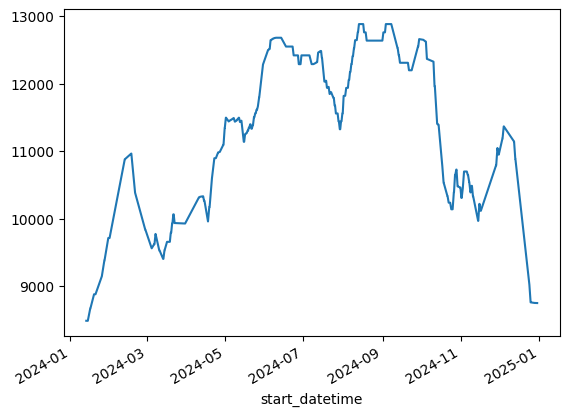

In [155]:
clear_sky_2024.plot()

In [156]:
num_features = 10

model_tcn = build_tcn_model(
    num_features=num_features,
    forecast_horizon=24
)

model_tcn.load_state_dict(
    torch.load("tcn_MSTL_ClearProxycloud_factor_2020_2023.pt", map_location="cpu")
)

cloud_factor_hourly = cloud_factor_day.reindex(
    pd.date_range(
        cloud_factor_day.index.min(),
        cloud_factor_day.index.max(),
        freq="h"
    )
)

cloud_factor_hourly = cloud_factor_hourly.fillna(0)
# solar_forecast = forecast_2024_tcn_fast(
#     model=model_tcn,
#     clear_sky_2024=clean_sky_2024,
#     cloud_factor_history=cloud_factor_hourly,
#     history=168,
#     horizon=24,
#     device="cpu"
# )

solar_forecast = forecast_2024_daily_teacher_forcing(
    model=model_tcn,
    clear_sky_2024=clear_sky_2024,
    actual_production=solar["Production"],
    history=168,
    device="cpu"
)

In [159]:
actual = solar.loc["2024", "Production"]

forecast = solar_forecast.reindex(actual.index)

metrics = evaluate_forecast(
    actual,
    forecast
)

print(metrics)

{'RMSE': 6196.86964402658, 'MAE': 5373.478297289485, 'MAPE (%)': 107.24454639728044, 'SMAPE (%)': 115.7696423233344, 'nRMSE': 1.000244011209028}


## One Day Forecast

In [160]:
actual = solar.loc["2024", "Production"]
forecast = solar_forecast.reindex(actual.index)

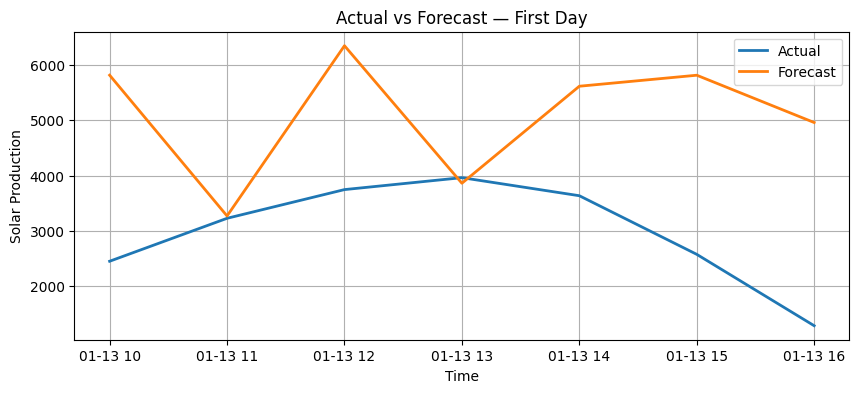

In [161]:
import matplotlib.pyplot as plt

first_day = actual.index.normalize().unique()[0]

plt.figure(figsize=(10,4))

plt.plot(
    actual.loc[first_day.strftime("%Y-%m-%d")],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast.loc[first_day.strftime("%Y-%m-%d")],
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast — First Day")
plt.xlabel("Time")
plt.ylabel("Solar Production")
plt.grid(True)
plt.legend()

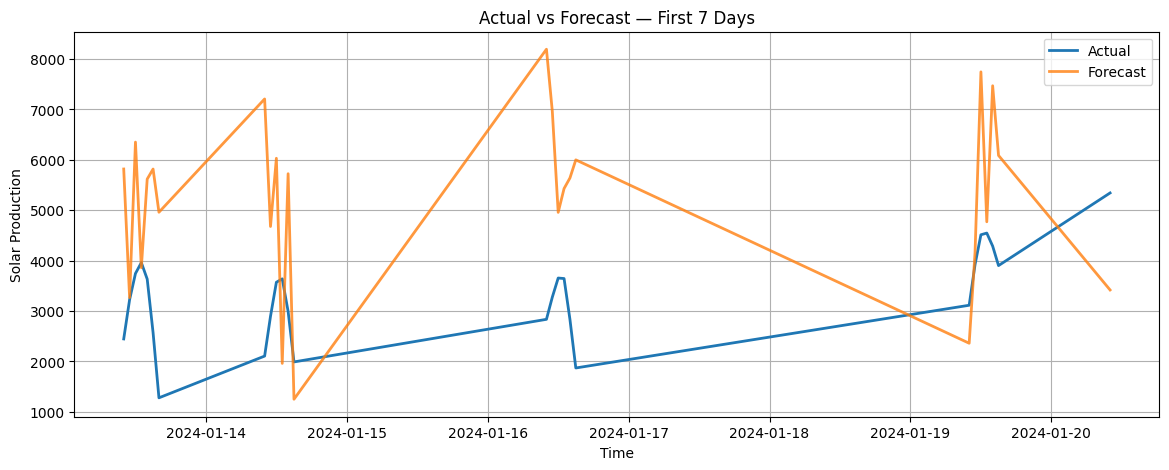

In [162]:
start = actual.index[0]
end = start + pd.Timedelta(days=7)

plt.figure(figsize=(14,5))

plt.plot(
    actual.loc[start:end],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast.loc[start:end],
    label="Forecast",
    linewidth=2,
    alpha=0.8
)

plt.title("Actual vs Forecast — First 7 Days")
plt.xlabel("Time")
plt.ylabel("Solar Production")
plt.grid(True)
plt.legend()

<Axes: xlabel='start_datetime'>

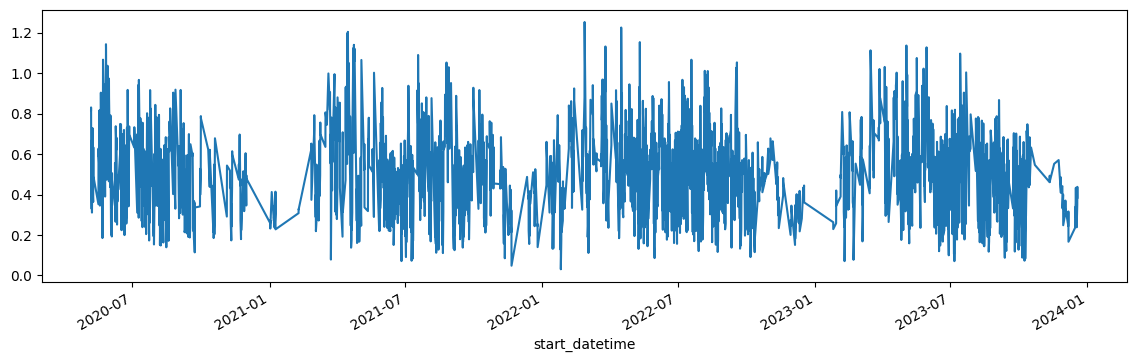

In [163]:
cf = solar["Production"] / clear_sky_proxy.replace(0, np.nan)

cf.plot(figsize=(14,4))

<Axes: >

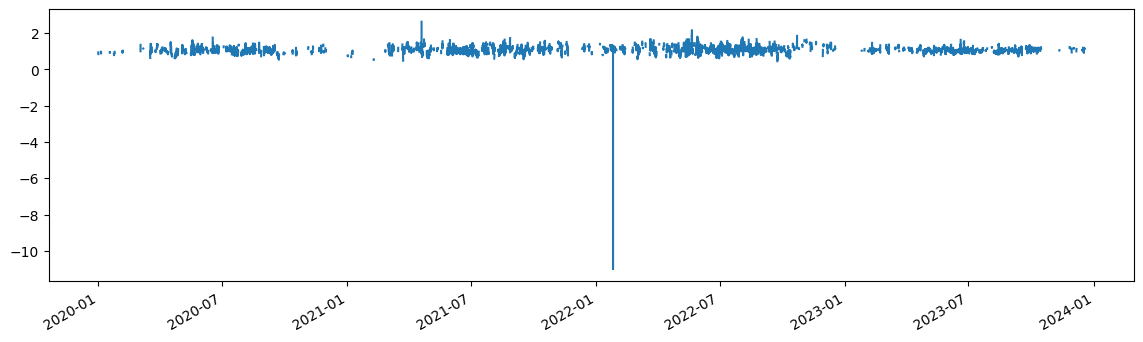

In [127]:
clear_sky_proxy = trend + seasonal_24 + seasonal_8760

cf = solar["Production"] / clear_sky_proxy.replace(0, np.nan)

cf.plot(figsize=(14,4))

## One week Forecast

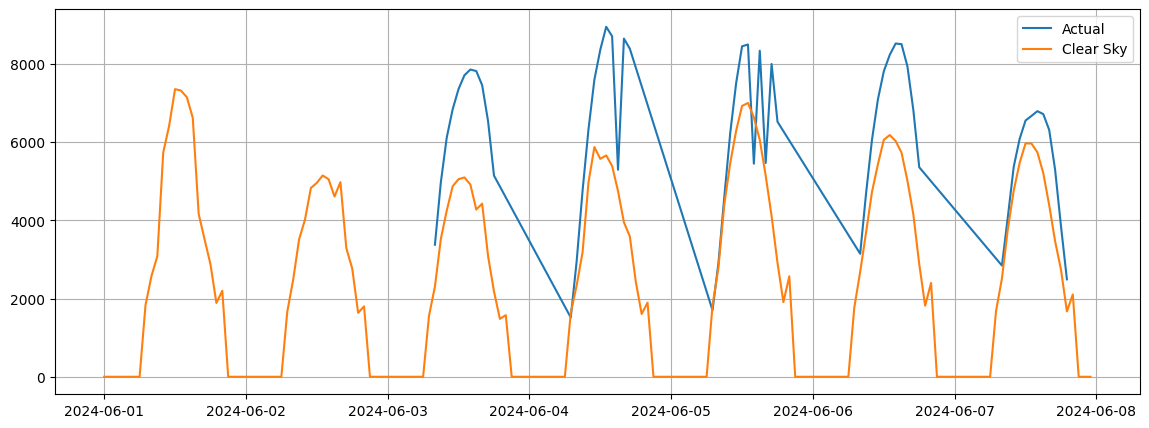

In [164]:
week = ("2024-06-01", "2024-06-07")

plt.figure(figsize=(14,5))
plt.plot(actual.loc[week[0]:week[1]], label="Actual")
plt.plot(clean_sky_2024.loc[week[0]:week[1]], label="Clear Sky")
plt.legend()
plt.grid()